In [1]:
import numpy as np
import matplotlib.pyplot as plt

from vs_ns_periodic_mrSAV_solver import vs_mrSAV_Vorticity_Stream_Periodic_Solver as vs_mrSAV_solver


In [ ]:
# Manufactured exact solution with a nonzero nonlinear convection term.
# The exact vorticity is generated from
#   psi(t,x,y) = a(t) * [sin(x)sin(y) + 0.35 sin(2x)sin(y)]
# where a(t) = 1 + 0.3 cos(4t).
# The amplitude oscillates without overall decay, and the two modes make u · grad(omega) nonzero.

nu = 1 / 50
gamma = 1000
s_domain = (0.0, 0.0, 2 * np.pi, 2 * np.pi)
discrete_num = [64, 64]
t_period = (0.0, 10.0)
tau_list = [0.001, 0.002, 0.004]
tau_ref = min(tau_list) / 2
method = "ETD_mrGSAV_MS2_b"
ref_method = "ETDRK4"

modes = [
    (1, 1, 1.0),
    (2, 1, 0.35),
]

xn = np.linspace(s_domain[0], s_domain[2], discrete_num[0] + 1)
yn = np.linspace(s_domain[1], s_domain[3], discrete_num[1] + 1)
X, Y = np.meshgrid(xn, yn)


def time_amplitude(t):
    return 1 + 0.3 * np.cos(4 * t)


def time_amplitude_derivative(t):
    return -1.2 * np.sin(4 * t)


def spatial_omega(x, y):
    omega = np.zeros_like(x, dtype=np.float64)
    for kx, ky, amp in modes:
        k2 = kx**2 + ky**2
        omega += amp * k2 * np.sin(kx * x) * np.sin(ky * y)
    return omega


def spatial_velocity(x, y):
    u = np.zeros_like(x, dtype=np.float64)
    v = np.zeros_like(x, dtype=np.float64)
    for kx, ky, amp in modes:
        u += amp * ky * np.sin(kx * x) * np.cos(ky * y)
        v += -amp * kx * np.cos(kx * x) * np.sin(ky * y)
    return u, v


def spatial_omega_grad(x, y):
    omega_x = np.zeros_like(x, dtype=np.float64)
    omega_y = np.zeros_like(x, dtype=np.float64)
    for kx, ky, amp in modes:
        k2 = kx**2 + ky**2
        omega_x += amp * k2 * kx * np.cos(kx * x) * np.sin(ky * y)
        omega_y += amp * k2 * ky * np.sin(kx * x) * np.cos(ky * y)
    return omega_x, omega_y


def spatial_lap_omega(x, y):
    lap = np.zeros_like(x, dtype=np.float64)
    for kx, ky, amp in modes:
        k2 = kx**2 + ky**2
        lap += -amp * k2**2 * np.sin(kx * x) * np.sin(ky * y)
    return lap


def exact_omega(x, y, t):
    return time_amplitude(t) * spatial_omega(x, y)


def exact_velocity(x, y, t):
    a = time_amplitude(t)
    u, v = spatial_velocity(x, y)
    return a * u, a * v


def exact_omega_grad(x, y, t):
    a = time_amplitude(t)
    omega_x, omega_y = spatial_omega_grad(x, y)
    return a * omega_x, a * omega_y


def exact_lap_omega(x, y, t):
    return time_amplitude(t) * spatial_lap_omega(x, y)


def exact_omega_t(x, y, t):
    return time_amplitude_derivative(t) * spatial_omega(x, y)


def exact_nonlinear_term(x, y, t):
    u, v = exact_velocity(x, y, t)
    omega_x, omega_y = exact_omega_grad(x, y, t)
    return -(u * omega_x + v * omega_y)


def force_term(x, y, t):
    return exact_omega_t(x, y, t) - nu * exact_lap_omega(x, y, t) - exact_nonlinear_term(x, y, t)


initial_condition = exact_omega(X, Y, t_period[0])


In [3]:
# Check that the analytic nonlinear term matches the solver's discrete N(omega).
check_solver = vs_mrSAV_solver(
    nu,
    gamma,
    s_domain,
    discrete_num,
    initial_condition,
    force_term,
    method,
)
X_cell = X[:-1, :-1]
Y_cell = Y[:-1, :-1]
N_discrete = check_solver.N(check_solver.Omega0)
N_exact = exact_nonlinear_term(X_cell, Y_cell, 0.0)
print(f"max |N_exact|: {np.max(np.abs(N_exact)):.6e}")
print(f"max |N_discrete - N_exact|: {np.max(np.abs(N_discrete - N_exact)):.6e}")


max |N_exact|: 1.774500e+00
max |N_discrete - N_exact|: 2.464695e-14


In [4]:
# Compute the fine ETDRK4 reference once. Every tau in tau_list is aligned with tau_ref.
solver_ref = vs_mrSAV_solver(
    nu,
    gamma,
    s_domain,
    discrete_num,
    initial_condition,
    force_term,
    ref_method,
)
solver_ref.solve_fix_step(t_period, tau_ref)

omega_exact_ref_grid = np.array([exact_omega(X_cell, Y_cell, t) for t in solver_ref.tn])
ref_grid_err = solver_ref.Omega - omega_exact_ref_grid
ref_grid_l2_exact_norm = np.sqrt(solver_ref.h * np.sum(omega_exact_ref_grid**2, axis=(1, 2)))
relative_l2_ref_error_vs_exact = (
    np.sqrt(solver_ref.h * np.sum(ref_grid_err**2, axis=(1, 2))) / ref_grid_l2_exact_norm
)
max_ref_error_vs_exact = np.max(np.abs(ref_grid_err), axis=(1, 2))

error_results = []

for tau in tau_list:
    ratio = tau / tau_ref
    if not np.isclose(ratio, np.rint(ratio), rtol=0.0, atol=1e-12):
        raise ValueError(f"tau={tau} is not aligned with tau_ref={tau_ref}")
    ref_stride = int(np.rint(ratio))

    solver = vs_mrSAV_solver(
        nu,
        gamma,
        s_domain,
        discrete_num,
        initial_condition,
        force_term,
        method,
    )
    solver.solve_fix_step(t_period, tau)

    omega_ref = solver_ref.Omega[::ref_stride]
    ref_tn = solver_ref.tn[::ref_stride]
    if len(ref_tn) != len(solver.tn) or not np.allclose(ref_tn, solver.tn, rtol=0.0, atol=1e-12):
        raise ValueError(f"Reference grid is not aligned for tau={tau}")

    omega_exact = np.array([exact_omega(X_cell, Y_cell, t) for t in solver.tn])

    err_exact = solver.Omega - omega_exact
    err_ref = solver.Omega - omega_ref
    l2_exact_norm = np.sqrt(solver.h * np.sum(omega_exact**2, axis=(1, 2)))

    l2_error_vs_exact = np.sqrt(solver.h * np.sum(err_exact**2, axis=(1, 2)))
    relative_l2_error_vs_exact = l2_error_vs_exact / l2_exact_norm
    max_error_vs_exact = np.max(np.abs(err_exact), axis=(1, 2))

    l2_error_vs_ref = np.sqrt(solver.h * np.sum(err_ref**2, axis=(1, 2)))
    relative_l2_error_vs_ref = l2_error_vs_ref / l2_exact_norm
    max_error_vs_ref = np.max(np.abs(err_ref), axis=(1, 2))

    error_results.append({
        "tau": tau,
        "tn": solver.tn.copy(),
        "relative_l2_error_vs_exact": relative_l2_error_vs_exact,
        "relative_l2_error_vs_ref": relative_l2_error_vs_ref,
        "max_error_vs_exact": max_error_vs_exact,
        "max_error_vs_ref": max_error_vs_ref,
    })

    print(
        f"tau={tau:g}: final rel L2 vs exact={relative_l2_error_vs_exact[-1]:.6e}, "
        f"vs ref={relative_l2_error_vs_ref[-1]:.6e}"
    )


 10.000000\10.0, Elapse: 0.003 s, Vorticity Energy:8.2493, Enstrophy:22.3008, Palinstrophy:73.6123, Maximum:2.62, |q-1|:0.0000e+00      
 10.000000\10.0, Elapse: 0.002 s, Vorticity Energy:8.2493, Enstrophy:22.3008, Palinstrophy:73.6122, Maximum:2.62, |q-1|:7.0388e-13      
tau=0.001: final rel L2 vs exact=4.121454e-07, vs ref=4.121456e-07
 10.000000\10.0, Elapse: 0.002 s, Vorticity Energy:8.2493, Enstrophy:22.3007, Palinstrophy:73.6122, Maximum:2.62, |q-1|:8.2243e-12      
tau=0.002: final rel L2 vs exact=1.651364e-06, vs ref=1.651364e-06
 10.000000\10.0, Elapse: 0.002 s, Vorticity Energy:8.2492, Enstrophy:22.3006, Palinstrophy:73.6119, Maximum:2.62, |q-1|:1.1563e-10      
tau=0.004: final rel L2 vs exact=6.627684e-06, vs ref=6.627684e-06


In [5]:
def random_tau_partition(t_period, tau_min=1e-5, tau_max=5e-3, mean_tau=None, seed=2026):
    T0, T1 = t_period
    total_T = T1 - T0
    rng = np.random.default_rng(seed)

    if total_T <= 0:
        raise ValueError("t_period must satisfy T1 > T0.")
    if tau_min <= 0 or tau_max <= 0 or tau_min > tau_max:
        raise ValueError("Require 0 < tau_min <= tau_max.")

    n_min = int(np.ceil(total_T / tau_max))
    n_max = int(np.floor(total_T / tau_min))
    if n_min > n_max:
        raise ValueError("Cannot partition this interval with the requested tau bounds.")

    if mean_tau is None:
        mean_tau = 0.5 * (tau_min + tau_max)
    n_steps = int(round(total_T / mean_tau))
    n_steps = min(max(n_steps, n_min), n_max)

    tau = np.empty(n_steps, dtype=np.float64)
    remaining = total_T
    for k in range(n_steps - 1):
        steps_left = n_steps - k - 1
        low = max(tau_min, remaining - steps_left * tau_max)
        high = min(tau_max, remaining - steps_left * tau_min)
        tau[k] = rng.uniform(low, high)
        remaining -= tau[k]

    tau[-1] = remaining

    if not (
        np.all(tau >= tau_min - 1e-14)
        and np.all(tau <= tau_max + 1e-14)
        and np.isclose(tau.sum(), total_T, rtol=0.0, atol=1e-12)
    ):
        raise ValueError("Random tau partition failed.")

    return tau


tau_random = random_tau_partition(t_period, tau_min=1e-5, tau_max=5e-3, seed=2026)

solver_rs = vs_mrSAV_solver(
    nu,
    gamma,
    s_domain,
    discrete_num,
    initial_condition,
    force_term,
    ref_method,
)
solver_rs.solve_given_tau(t_period, tau_random)

omega_exact_rs = np.array([exact_omega(X_cell, Y_cell, t) for t in solver_rs.tn])
err_rs = solver_rs.Omega - omega_exact_rs

l2_exact_norm_rs = np.sqrt(solver_rs.h * np.sum(omega_exact_rs**2, axis=(1, 2)))
l2_error_rs = np.sqrt(solver_rs.h * np.sum(err_rs**2, axis=(1, 2)))
relative_l2_error_rs = l2_error_rs / l2_exact_norm_rs
max_error_rs = np.max(np.abs(err_rs), axis=(1, 2))

random_step_result = {
    "tau": tau_random,
    "tn": solver_rs.tn.copy(),
    "relative_l2_error_vs_exact": relative_l2_error_rs,
    "l2_error_vs_exact": l2_error_rs,
    "max_error_vs_exact": max_error_rs,
}

print("random tau partition")
print(f"  steps: {len(tau_random)}")
print(f"  min tau: {tau_random.min():.6e}")
print(f"  max tau: {tau_random.max():.6e}")
print(f"  sum tau: {tau_random.sum():.12f}")
print(f"  final relative L2 error vs exact: {relative_l2_error_rs[-1]:.6e}")
print(f"  max relative L2 error vs exact on {t_period}: {relative_l2_error_rs.max():.6e}")
print(f"  max error vs exact on {t_period}: {max_error_rs.max():.6e}")


 10.000000\10.000000000000025, tau = 0.000010, Elapse: 0.008 s, Vorticity Energy:8.2493, Enstrophy:22.3008, Palinstrophy:73.6123, Maximum:2.62, |q-1|:0.0000e+00      
random tau partition
  steps: 3992
  min tau: 1.000003e-05
  max tau: 4.999783e-03
  sum tau: 10.000000000000
  final relative L2 error vs exact: 3.010666e-11
  max relative L2 error vs exact on (0.0, 10.0): 4.107252e-11
  max error vs exact on (0.0, 10.0): 9.234435e-11


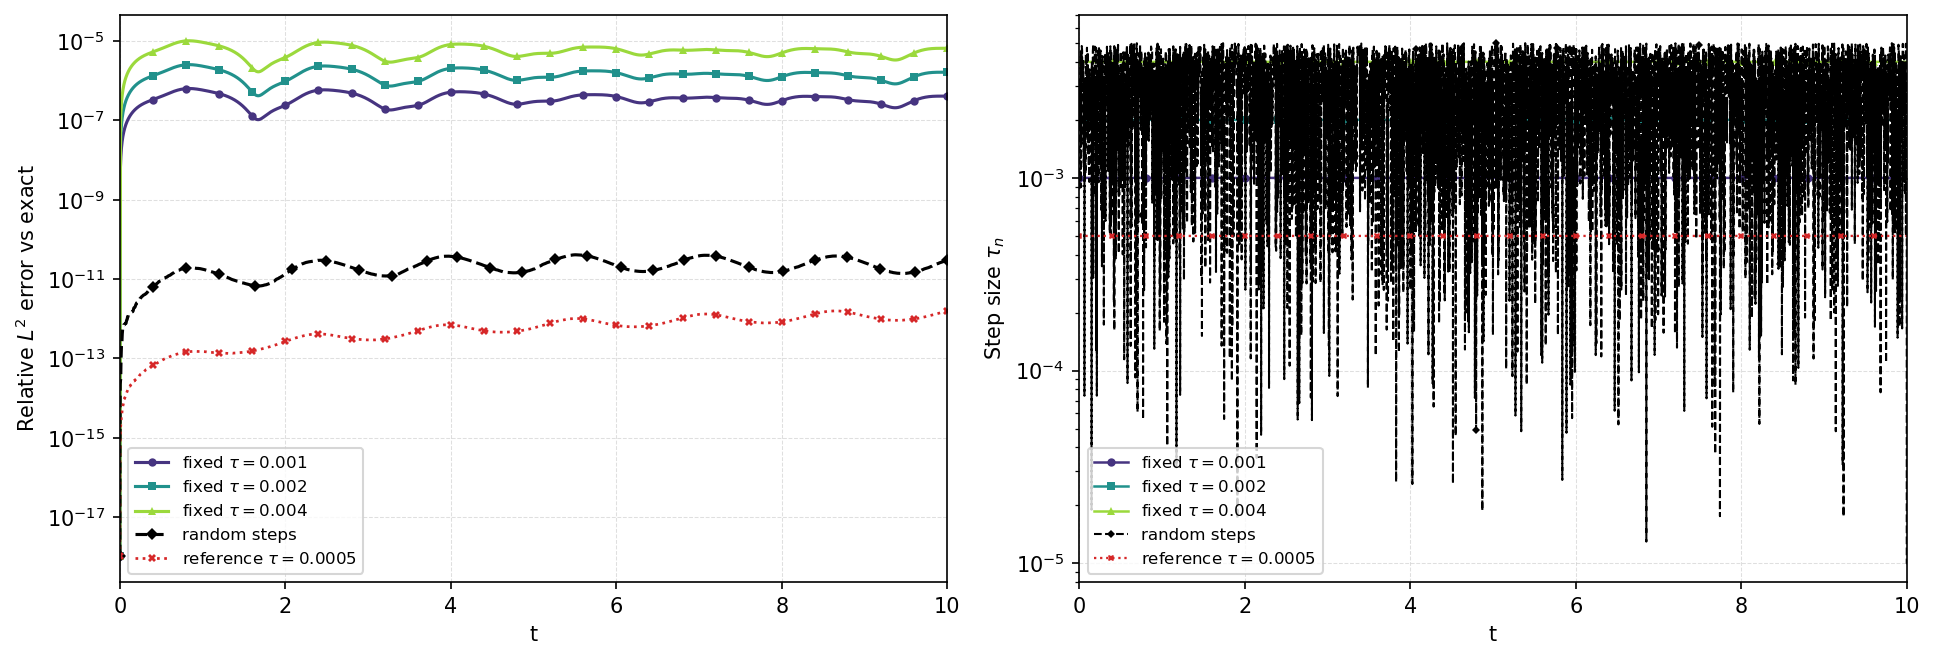

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=150)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(error_results)))
markers = ["o", "s", "^"]

# Left: relative L2 error evolution in time.
for color, marker, res in zip(colors, markers, error_results):
    markevery = max(1, len(res["tn"]) // 25)
    axes[0].semilogy(
        res["tn"],
        res["relative_l2_error_vs_exact"],
        color=color,
        lw=1.5,
        marker=marker,
        markersize=4,
        markeredgewidth=0,
        markevery=markevery,
        label=rf"fixed $\tau={res['tau']:g}$",
    )

random_markevery = max(1, len(random_step_result["tn"]) // 25)
axes[0].semilogy(
    random_step_result["tn"],
    random_step_result["relative_l2_error_vs_exact"],
    color="black",
    lw=1.5,
    ls="--",
    marker="D",
    markersize=4,
    markeredgewidth=0,
    markevery=random_markevery,
    label="random steps",
)

ref_markevery = max(1, len(solver_ref.tn) // 25)
axes[0].semilogy(
    solver_ref.tn,
    relative_l2_ref_error_vs_exact,
    color="tab:red",
    lw=1.3,
    ls=":",
    marker="X",
    markersize=4,
    markeredgewidth=0,
    markevery=ref_markevery,
    label=rf"reference $\tau={tau_ref:g}$",
)

axes[0].set_xlabel("t")
axes[0].set_ylabel(r"Relative $L^2$ error vs exact")
axes[0].set_xlim(*t_period)
axes[0].grid(alpha=0.4, linestyle="--", linewidth=0.5)
axes[0].legend(loc="best", fontsize=8)

# Right: step-size evolution in time.
for color, marker, res in zip(colors, markers, error_results):
    tau = float(res["tau"])
    t_step = res["tn"][1:]
    tau_step = np.full_like(t_step, tau, dtype=float)
    markevery = max(1, len(t_step) // 25)
    axes[1].semilogy(
        t_step,
        tau_step,
        color=color,
        lw=1.2,
        marker=marker,
        markersize=4,
        markeredgewidth=0,
        markevery=markevery,
        label=rf"fixed $\tau={tau:g}$",
    )

random_t_step = random_step_result["tn"][1:]
random_tau = random_step_result["tau"]
random_tau_markevery = max(1, len(random_tau) // 40)
axes[1].semilogy(
    random_t_step,
    random_tau,
    color="black",
    lw=1.0,
    ls="--",
    marker="D",
    markersize=3,
    markeredgewidth=0,
    markevery=random_tau_markevery,
    label="random steps",
)

axes[1].semilogy(
    solver_ref.tn[1:],
    np.full_like(solver_ref.tn[1:], tau_ref, dtype=float),
    color="tab:red",
    lw=1.1,
    ls=":",
    marker="X",
    markersize=3,
    markeredgewidth=0,
    markevery=max(1, len(solver_ref.tn[1:]) // 25),
    label=rf"reference $\tau={tau_ref:g}$",
)

axes[1].set_xlabel("t")
axes[1].set_ylabel(r"Step size $\tau_n$")
axes[1].set_xlim(*t_period)
axes[1].set_ylim(8e-6, 7e-3)
axes[1].grid(alpha=0.4, linestyle="--", linewidth=0.5)
axes[1].legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()


In [6]:
for res in error_results:
    print(f"tau = {res['tau']:g}")
    print(f"  final relative L2 error vs exact: {res['relative_l2_error_vs_exact'][-1]:.6e}")
    print(f"  final relative L2 error vs reference: {res['relative_l2_error_vs_ref'][-1]:.6e}")
    print(f"  max relative L2 error vs exact on {t_period}: {res['relative_l2_error_vs_exact'].max():.6e}")
    print(f"  max relative L2 error vs reference on {t_period}: {res['relative_l2_error_vs_ref'].max():.6e}")

print("reference solution")
print(f"  max relative L2 error vs exact on {t_period}: {relative_l2_ref_error_vs_exact.max():.6e}")
print(f"  max error vs exact on {t_period}: {max_ref_error_vs_exact.max():.6e}")


tau = 0.001
  final relative L2 error vs exact: 4.121454e-07
  final relative L2 error vs reference: 4.121456e-07
  max relative L2 error vs exact on (0.0, 10.0): 6.407604e-07
  max relative L2 error vs reference on (0.0, 10.0): 6.407605e-07
tau = 0.002
  final relative L2 error vs exact: 1.651364e-06
  final relative L2 error vs reference: 1.651364e-06
  max relative L2 error vs exact on (0.0, 10.0): 2.562146e-06
  max relative L2 error vs reference on (0.0, 10.0): 2.562146e-06
tau = 0.004
  final relative L2 error vs exact: 6.627684e-06
  final relative L2 error vs reference: 6.627684e-06
  max relative L2 error vs exact on (0.0, 10.0): 1.024117e-05
  max relative L2 error vs reference on (0.0, 10.0): 1.024117e-05
reference solution
  max relative L2 error vs exact on (0.0, 10.0): 1.580871e-12
  max error vs exact on (0.0, 10.0): 4.326761e-12


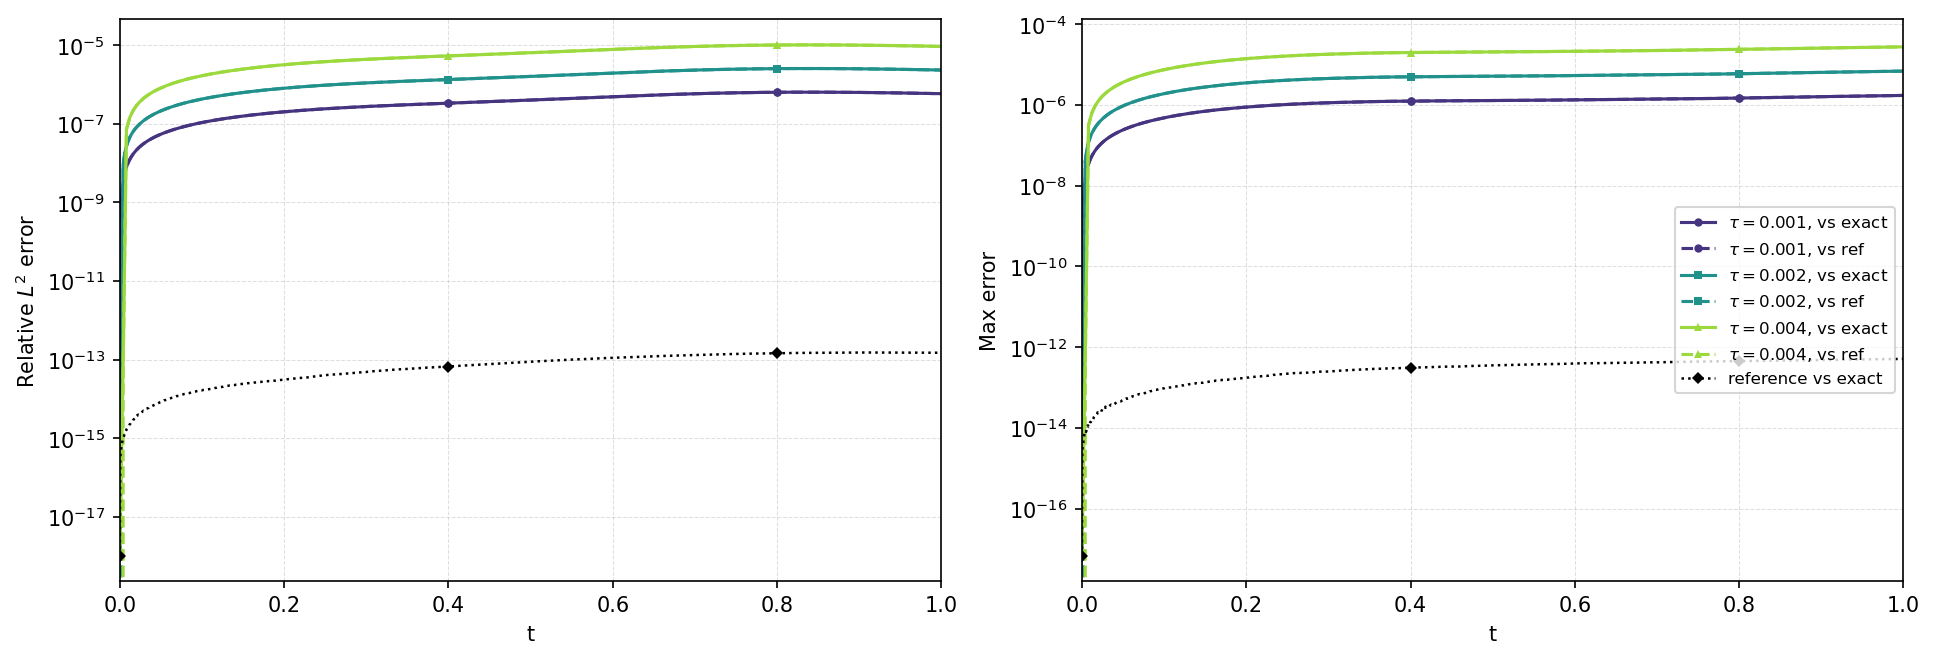

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=150)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(error_results)))
markers = ["o", "s", "^"]

for color, marker, res in zip(colors, markers, error_results):
    label = rf"$\tau={res['tau']:g}$"
    markevery = max(1, len(res["tn"]) // 25)
    marker_kwargs = dict(marker=marker, markersize=4, markeredgewidth=0, markevery=markevery)

    axes[0].semilogy(res["tn"], res["relative_l2_error_vs_exact"], color=color, lw=1.5,
                     label=label + ", vs exact", **marker_kwargs)
    axes[0].semilogy(res["tn"], res["relative_l2_error_vs_ref"], color=color, lw=1.5, ls="--",
                     label=label + ", vs ref", **marker_kwargs)
    axes[1].semilogy(res["tn"], res["max_error_vs_exact"], color=color, lw=1.5,
                     label=label + ", vs exact", **marker_kwargs)
    axes[1].semilogy(res["tn"], res["max_error_vs_ref"], color=color, lw=1.5, ls="--",
                     label=label + ", vs ref", **marker_kwargs)

ref_markevery = max(1, len(solver_ref.tn) // 25)
ref_marker_kwargs = dict(marker="D", markersize=4, markeredgewidth=0, markevery=ref_markevery)
axes[0].semilogy(solver_ref.tn, relative_l2_ref_error_vs_exact, color="black", lw=1.2, ls=":",
                 label="reference vs exact", **ref_marker_kwargs)
axes[1].semilogy(solver_ref.tn, max_ref_error_vs_exact, color="black", lw=1.2, ls=":",
                 label="reference vs exact", **ref_marker_kwargs)

axes[0].set_xlabel("t")
axes[0].set_ylabel("Relative $L^2$ error")
axes[0].set_xlim(0,1)
axes[0].grid(alpha=0.4, linestyle="--", linewidth=0.5)
# axes[0].legend(loc="best", fontsize=8)

axes[1].set_xlabel("t")
axes[1].set_ylabel("Max error")
axes[1].set_xlim(0,1)
axes[1].grid(alpha=0.4, linestyle="--", linewidth=0.5)
axes[1].legend(loc="center right", fontsize=8)

plt.tight_layout()
plt.show()
